# Analysis

My data analysis is seperated into 4 chapter - __Revenue, Products, Traffic and Sessions__. <br>



## Revenue Analysis

Here I discover the health of my test business.

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd


df_sales = pd.read_csv("C:/Projekt_Ordner/Sales_Analysis/Data/Cleaned_Data/df_sales.csv")
df_sessions = pd.read_csv("C:/Projekt_Ordner/Sales_Analysis/Data/Cleaned_Data/df_sessions.csv")

print(df_sales.shape)
print(df_sessions.shape)

(40025, 14)
(472871, 11)


__Monthly Revenue__

In [6]:
df_sales["created_at"] = pd.to_datetime(df_sales["created_at"])

df_sales["year_month"] = df_sales["created_at"].dt.to_period("M")


monthly_revenue = (df_sales.groupby("year_month").agg
                   (total_revenue = ("price_usd", "sum"), 
                    total_cost = ("cogs_usd", "sum"), 
                    total_profit = ("profit_usd", "sum"), 
                    total_orders = ("order_id", "nunique"), 
                    items_sold = ("order_item_id", "count"))
                .reset_index()
                    )


monthly_revenue["year_month_dt"] = monthly_revenue["year_month"].dt.to_timestamp()

print(monthly_revenue.to_string(index=False))

year_month  total_revenue  total_cost  total_profit  total_orders  items_sold year_month_dt
   2012-03        2999.40     1169.40        1830.0            60          60    2012-03-01
   2012-04        4949.01     1929.51        3019.5            99          99    2012-04-01
   2012-05        5398.92     2104.92        3294.0           108         108    2012-05-01
   2012-06        6998.60     2728.60        4270.0           140         140    2012-06-01
   2012-07        8448.31     3293.81        5154.5           169         169    2012-07-01
   2012-08       11397.72     4443.72        6954.0           228         228    2012-08-01
   2012-09       14347.13     5593.63        8753.5           287         287    2012-09-01
   2012-10       18546.29     7230.79       11315.5           371         371    2012-10-01
   2012-11       30893.82    12044.82       18849.0           618         618    2012-11-01
   2012-12       25294.94     9861.94       15433.0           506         506   

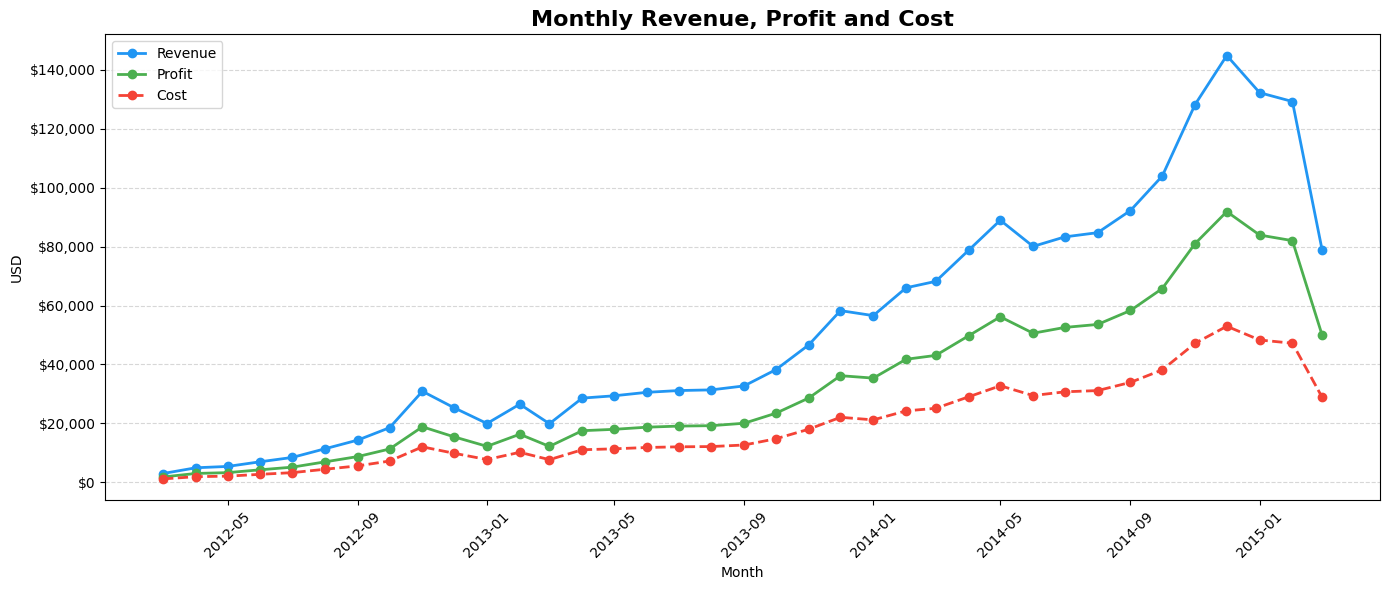

In [7]:
# Plot - Monthly Revenue, Cost and Profit

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_revenue"],
        marker= "o", label = "Revenue", color = "#2196F3", linewidth=2)
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_profit"],
        marker= "o", label = "Profit",  color = "#4CAF50", linewidth=2)
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_cost"],
        marker= "o", label = "Cost",    color = "#F44336", linewidth=2, linestyle="--")

ax.set_title("Monthly Revenue, Profit and Cost", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue is growing untill 2015 and declined then sharply. The Profit margin is stable. 

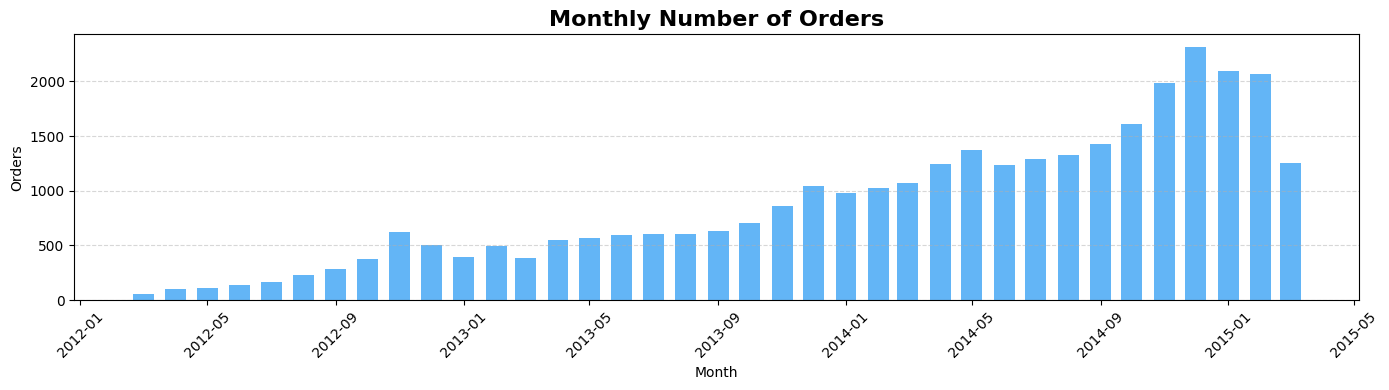

In [15]:
# Plot - Monthly Orders Volume

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(monthly_revenue["year_month_dt"], monthly_revenue["total_orders"], color="#2196F3", alpha=0.7, width=20)

ax.set_title("Monthly Number of Orders", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Monthly order figures have been rising steadily and at an ever-increasing rate since May 2014. Since 2015, monthly order figures have been falling.

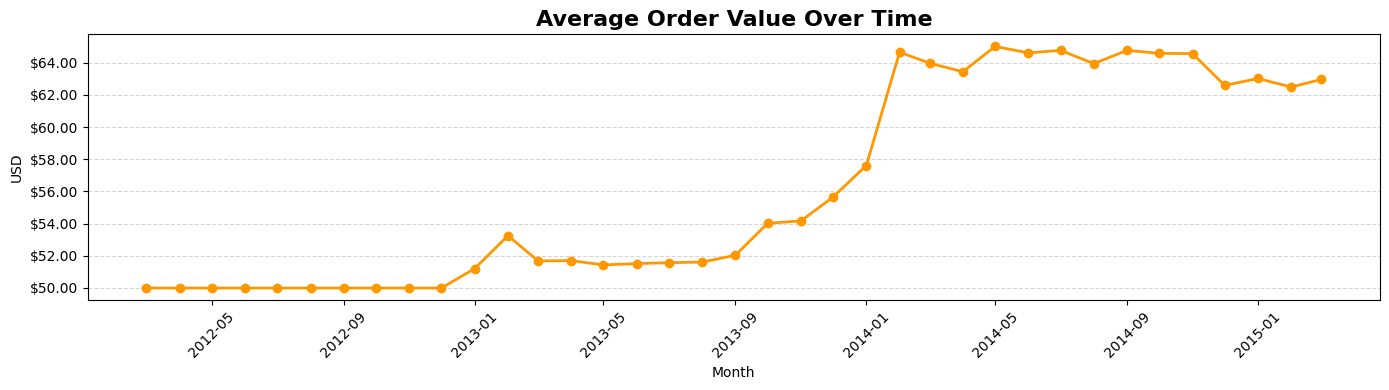

In [16]:
# Plot - Average Order Value over time

monthly_revenue["avg_order_value"] = (monthly_revenue["total_revenue"] / monthly_revenue["total_orders"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["avg_order_value"], marker="o", color="#FF9800", linewidth=2)

ax.set_title("Average Order Value Over Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Summary

To begin with, order values rise steadily and gradually. This changes between September 2023 and January 2024, when a sharp increase can be observed. Thereafter, the figures stabilise at a high level.


## Product Analysis

Here I analyse which products drive the most revenue, volume and profit.

In [8]:
product_summary = (df_sales.groupby("product_name").agg(total_revenue = ("price_usd", "sum"), 
                                                     total_cost = ("cogs_usd", "sum"),
                                                     total_profit = ("profit_usd", "sum"), 
                                                     units_sold = ("order_item_id", "count"),
                                                     avg_price = ("price_usd", "mean"))
                    .reset_index()
                    )

product_summary["profit_margin_%"] = ((product_summary["total_profit"] / product_summary["total_revenue"]) * 100).round(2)

product_summary = product_summary.sort_values("total_revenue", ascending=False)

print(product_summary.to_string(index=False))

              product_name  total_revenue  total_cost  total_profit  units_sold  avg_price  profit_margin_%
    The Original Mr. Fuzzy     1211057.74   472164.74      738893.0       24226      49.99            61.01
     The Forever Love Bear      347702.04   130352.04      217350.0        5796      59.99            62.51
  The Birthday Sugar Panda      229260.15    72232.65      157027.5        4985      45.99            68.49
The Hudson River Mini bear      150489.82    47620.82      102869.0        5018      29.99            68.36


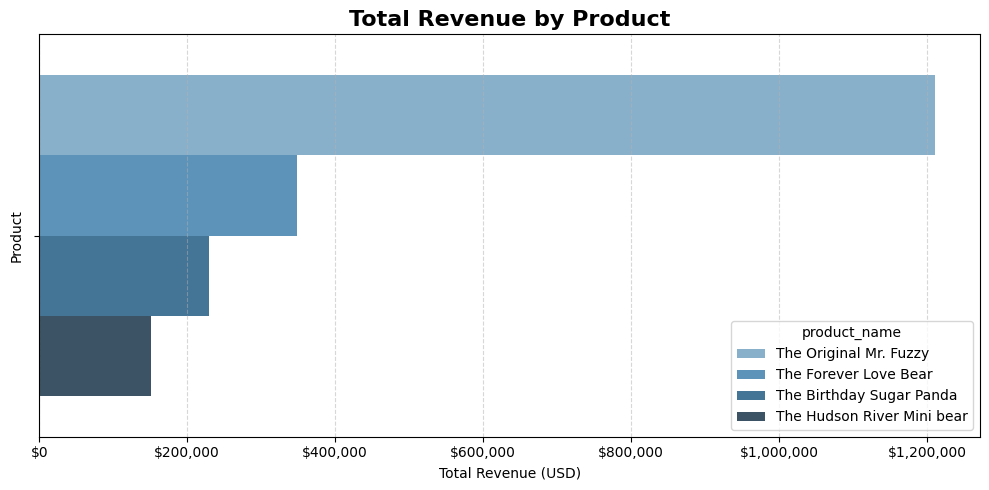

In [13]:
# Plot - Revenue by Product 

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=product_summary, x="total_revenue", hue="product_name", palette="Blues_d", ax=ax, legend="auto")

ax.set_title("Total Revenue by Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Revenue (USD)")
ax.set_ylabel("Product")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

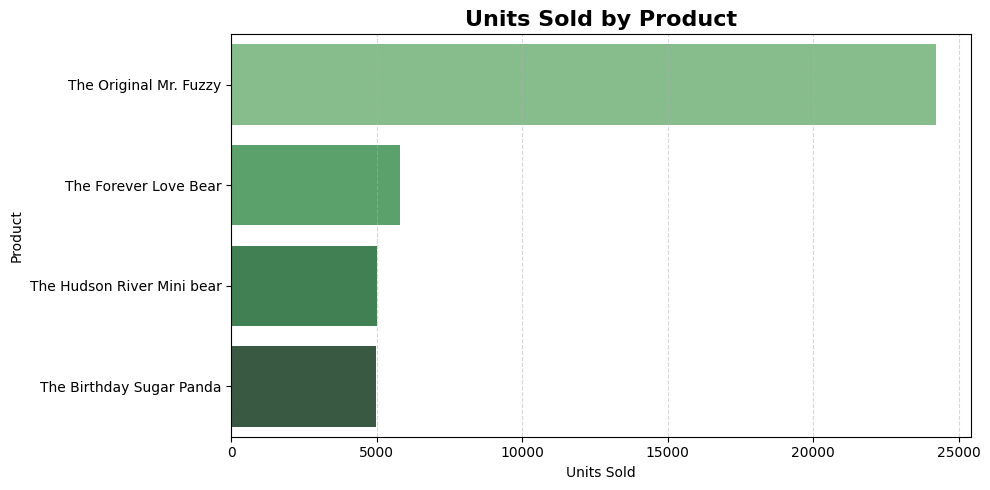

In [16]:
# Plot - Units Sold by Product

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=product_summary.sort_values("units_sold", ascending=False), 
            x="units_sold", y="product_name", hue="product_name", palette="Greens_d", ax=ax)

ax.set_title("Units Sold by Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Product")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

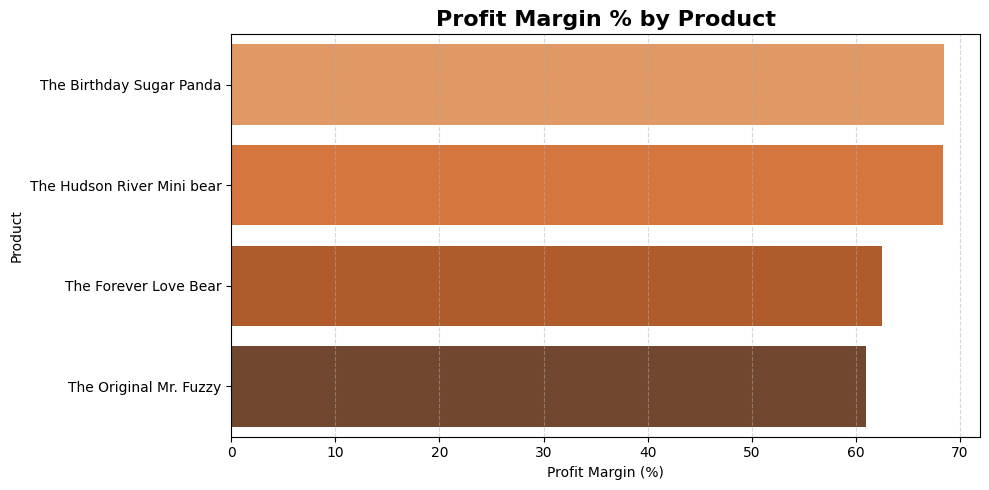

In [17]:
# Plot - Profit Margin by Product

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=product_summary.sort_values("profit_margin_%", ascending=False), 
            x="profit_margin_%", y="product_name", hue="product_name", palette="Oranges_d", ax=ax)

ax.set_title("Profit Margin % by Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Profit Margin (%)")
ax.set_ylabel("Product")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


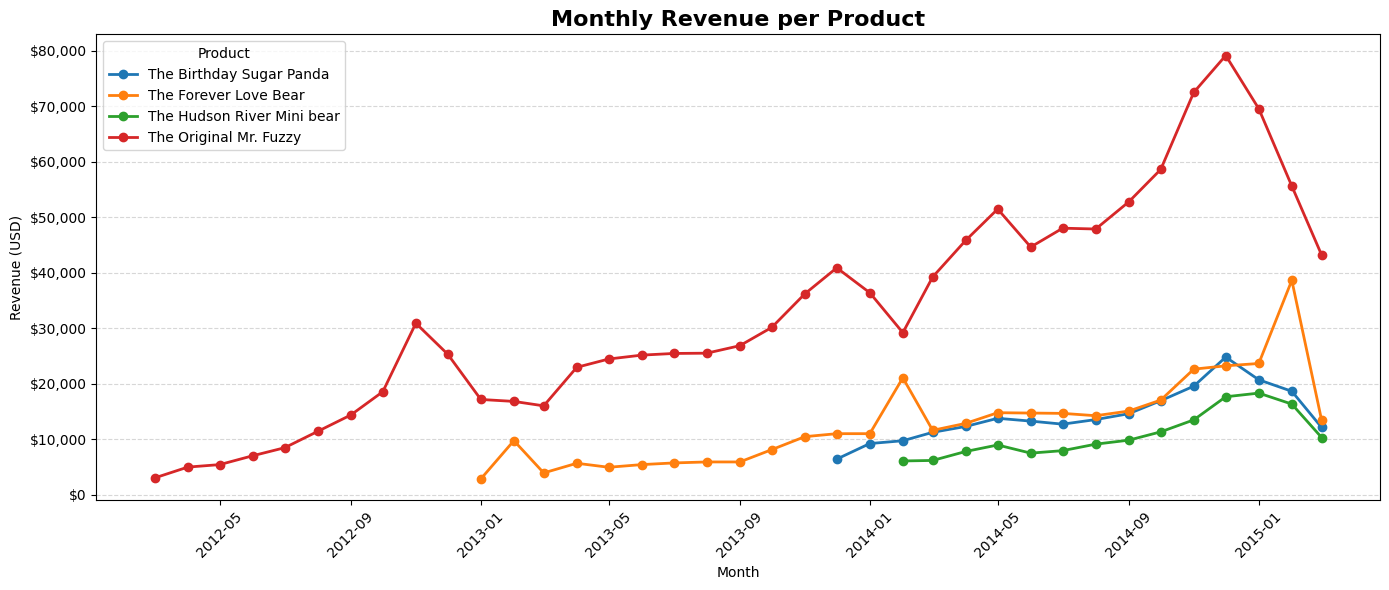

In [18]:
# Plot - Revenue Trend per Product Over Time

product_monthly = (df_sales.groupby(["year_month", "product_name"]).agg(
                total_revenue=("price_usd", "sum")).reset_index()
                )

product_monthly["year_month_dt"] = product_monthly["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))

for product, group in product_monthly.groupby("product_name"):
    ax.plot(group["year_month_dt"], group["total_revenue"],
            marker="o", linewidth=2, label=product)

ax.set_title("Monthly Revenue per Product", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Product")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [20]:

product_summary.style.format({"total_revenue": "${:,.2f}",
                              "total_cost": "${:,.2f}",
                              "total_profit": "${:,.2f}",
                              "avg_price": "${:,.2f}",
                              "profit_margin_%": "{:.1f}%",
                            }).background_gradient(subset=["profit_margin_%"], cmap="Greens")

,product_name,total_revenue,total_cost,total_profit,units_sold,avg_price,profit_margin_%
3,The Original Mr. Fuzzy,"$1,211,057.74","$472,164.74","$738,893.00",24226,$49.99,61.0%
1,The Forever Love Bear,"$347,702.04","$130,352.04","$217,350.00",5796,$59.99,62.5%
0,The Birthday Sugar Panda,"$229,260.15","$72,232.65","$157,027.50",4985,$45.99,68.5%
2,The Hudson River Mini bear,"$150,489.82","$47,620.82","$102,869.00",5018,$29.99,68.4%


### Summary

By far the best-selling product with the highest total revenue is “The Original Mr. Fuzzy” at $1,211,057.74, compared to the total revenue of the remaining products, which amounts to $727,452.01. “The Original Mr. Fuzzy” contributed the most to the total profit, at $738,893.00. Nevertheless, the profit margin is higher for the other products: it stands at 68.4% for “The Birthday Sugar Panda” and “The Hudson River Mini Bear”, compared to 61.0% for “The Original Mr. Fuzzy”.